# SpendSense: Personal Expense Analysis

Name: Rajat Tyagi  
Course: Introduction to Data Science  
University: IILM University  
Year: 2025

This project analyzes personal spending data using Python to identify financial trends and spending behavior.


---

## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12


---

## 2. Load Dataset


In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Create date range
dates = pd.date_range(start="2024-01-01", end="2024-12-31", freq="D")

# Categories
categories = ["Food", "Travel", "Shopping", "Bills", "Entertainment"]

# Payment modes
payment_modes = ["Cash", "UPI", "Card"]

# Generate synthetic dataset
data = {
    "Date": np.random.choice(dates, 300),
    "Category": np.random.choice(categories, 300),
    "Amount": np.random.randint(100, 5000, 300),
    "Payment Mode": np.random.choice(payment_modes, 300),
    "Description": "Expense"
}

df = pd.DataFrame(data)
df.head()


,Date,Category,Amount,Payment Mode,Description
0,2024-04-12,Food,3023,UPI,Expense
1,2024-12-14,Entertainment,2314,Cash,Expense
2,2024-09-27,Bills,4286,Card,Expense
3,2024-04-16,Shopping,813,UPI,Expense
4,2024-03-12,Food,3702,UPI,Expense


---

## 3. Dataset Overview

In this step, we explore the basic structure of the dataset. 
The functions used here help us understand the number of rows and columns, 
data types of each column, and overall information about the dataset.

- `df.info()` provides information about column names, data types, and non-null values.
- `df.shape` shows the total number of rows and columns in the dataset.
- `df.describe()` is a Pandas function used to get a statistical summary of the dataset.

In [3]:
df.info()
df.shape
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          300 non-null    datetime64[us]
 1   Category      300 non-null    str           
 2   Amount        300 non-null    int32         
 3   Payment Mode  300 non-null    str           
 4   Description   300 non-null    str           
dtypes: datetime64[us](1), int32(1), str(3)
memory usage: 10.7 KB


,Date,Amount
count,300,300.000000
mean,2024-07-06 10:43:12,2690.890000
min,2024-01-02 00:00:00,103.000000
25%,2024-04-16 18:00:00,1458.000000
50%,2024-07-06 12:00:00,2694.000000
75%,2024-09-24 12:00:00,4034.250000
max,2024-12-31 00:00:00,4992.000000
std,NaN,1445.394403


---

## 4. Monthly Expense Analysis

In this step, the total expenses for each month are calculated. 
The dataset is grouped by the Month column, and the total amount 
spent in each month is computed. This helps identify monthly 
spending patterns and trends over time.


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

monthly_expense = df.groupby('Month')['Amount'].sum().sort_index()


print(monthly_expense)


Month
1     43527
2     74587
3     41762
4     73542
5     92325
6     60273
7     64291
8     99724
9     71253
10    52919
11    52802
12    80262
Name: Amount, dtype: int32


In [5]:
category_expense = df.groupby('Category')['Amount'].sum()

category_expense

Category
Bills            149043
Entertainment    195859
Food             159045
Shopping         138574
Travel           164746
Name: Amount, dtype: int32

---

## 6. Expense Distribution (Pie Chart)


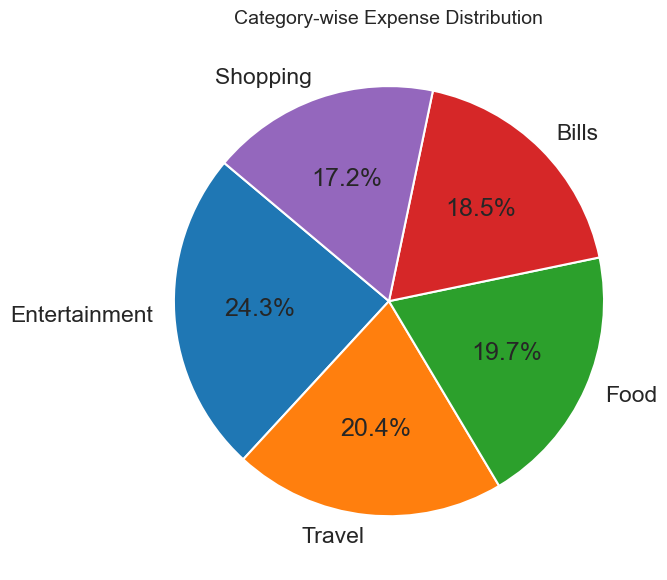

In [6]:
plt.figure(figsize=(7,7))

category_expense_sorted = category_expense.sort_values(ascending=False)

plt.pie(category_expense_sorted,
        labels=category_expense_sorted.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title("Category-wise Expense Distribution", fontsize=14)

plt.tight_layout()
plt.show()

---

## 7. Monthly Spending Trend (Line Graph)


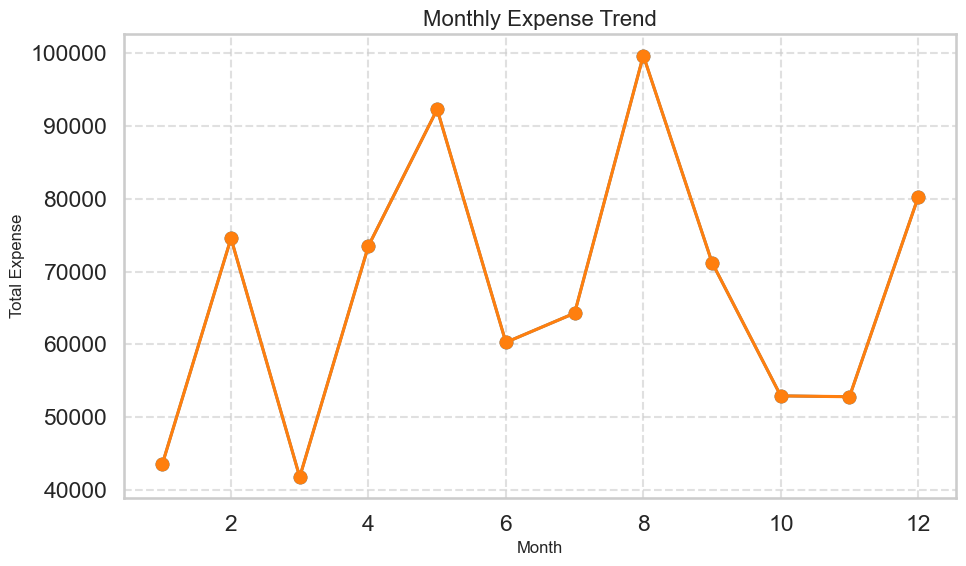

In [7]:

plt.figure(figsize=(10,6))

monthly_expense_sorted = monthly_expense.sort_index()

plt.plot(monthly_expense_sorted.index,
         monthly_expense_sorted.values,
         marker='o',
         linewidth=2)

plt.title("Monthly Expense Trend", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Expense (₹)", fontsize=12)

monthly_expense.plot(marker='o')
plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Total Expense")

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


---

## 8. Category Comparison (Bar Chart)


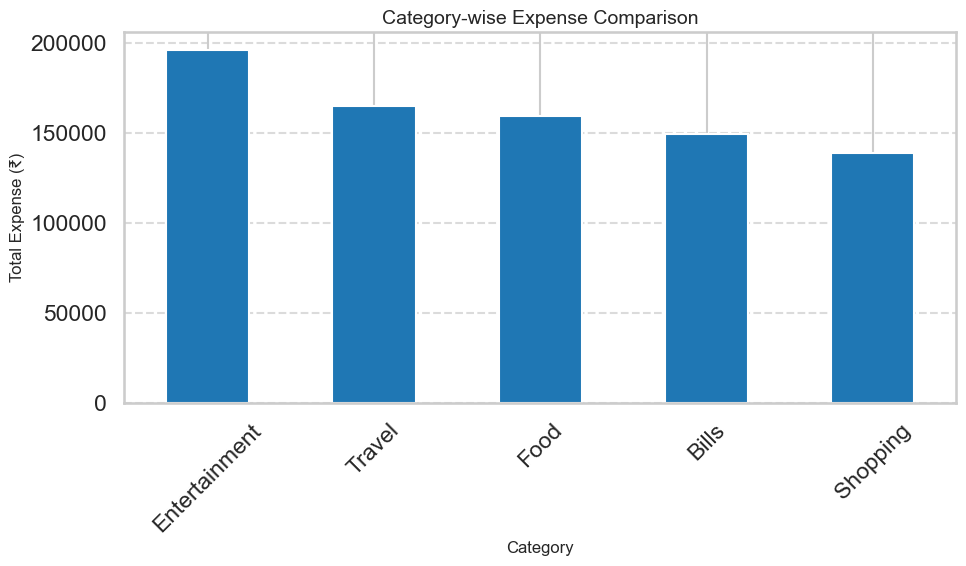

In [8]:
plt.figure(figsize=(10,6))

# Sort values for better visual impact
category_expense_sorted = category_expense.sort_values(ascending=False)

category_expense_sorted.plot(kind='bar')

plt.title("Category-wise Expense Comparison", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Expense (₹)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


---

## 9. Payment Mode Analysis


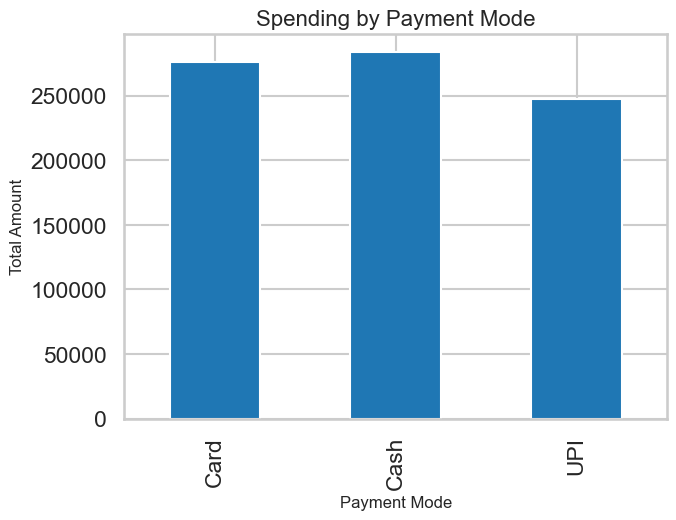

In [9]:
payment_sum = df.groupby("Payment Mode")["Amount"].sum()

plt.figure(figsize=(7,5))
payment_sum.plot(kind='bar')

plt.title("Spending by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Total Amount")
plt.show()


---

## 10. Top 10 Highest Expenses

In this step, the dataset is sorted based on the Amount column in 
descending order to identify the highest expenses. The top 10 
records are then displayed to highlight the largest individual 
spending transactions.


In [10]:
top_expenses = df.sort_values(by="Amount", ascending=False).head(10)

print(top_expenses)


          Date       Category  Amount Payment Mode Description  Month  \
151 2024-01-13  Entertainment    4992          UPI     Expense      1   
136 2024-02-11  Entertainment    4959         Cash     Expense      2   
124 2024-08-14  Entertainment    4958         Cash     Expense      8   
147 2024-05-22           Food    4954         Cash     Expense      5   
263 2024-01-02         Travel    4954          UPI     Expense      1   
9   2024-08-02  Entertainment    4949         Cash     Expense      8   
61  2024-02-19         Travel    4935         Card     Expense      2   
205 2024-04-22         Travel    4921         Cash     Expense      4   
100 2024-05-15       Shopping    4909         Cash     Expense      5   
71  2024-06-10  Entertainment    4904         Card     Expense      6   

    Month_Name  
151    January  
136   February  
124     August  
147        May  
263    January  
9       August  
61    February  
205      April  
100        May  
71        June  


---

## 11. Average Expense per Category

In this step, the average spending for each expense category is calculated. 
The dataset is grouped by the Category column, and the mean value of the 
Amount column is computed. This helps understand the typical spending 
level for each category.



In [11]:
avg_category = df.groupby("Category")["Amount"].mean()

print(avg_category)


Category
Bills            2443.327869
Entertainment    2838.536232
Food             2650.750000
Shopping         2828.040816
Travel           2700.754098
Name: Amount, dtype: float64


---

## 12. Spending Heatmap by Category and Month

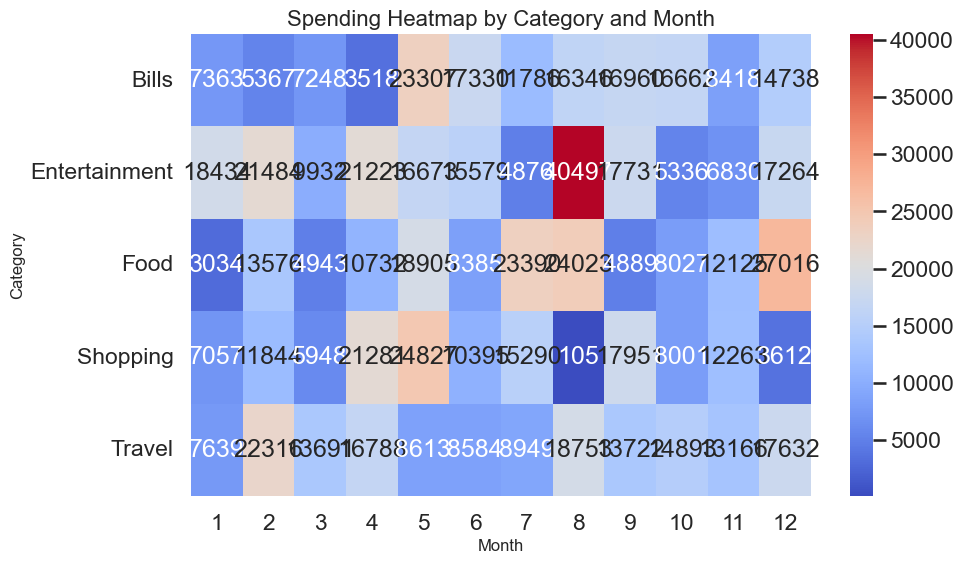

In [12]:
pivot = df.pivot_table(values="Amount", index="Category", columns="Month", aggfunc="sum")

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")

plt.title("Spending Heatmap by Category and Month")
plt.show()


---
## 13. FORECASTING (PROPHET)

20:42:45 - cmdstanpy - INFO - Chain [1] start processing
20:42:45 - cmdstanpy - INFO - Chain [1] done processing


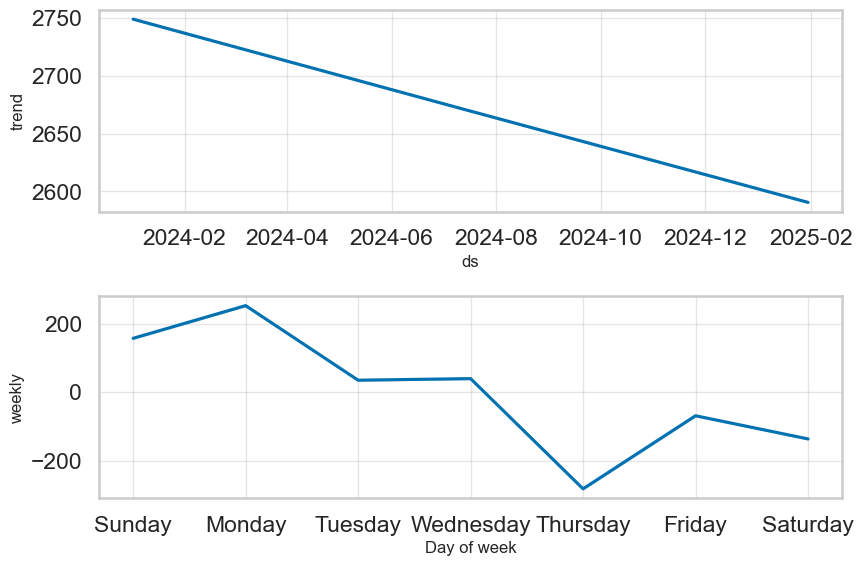

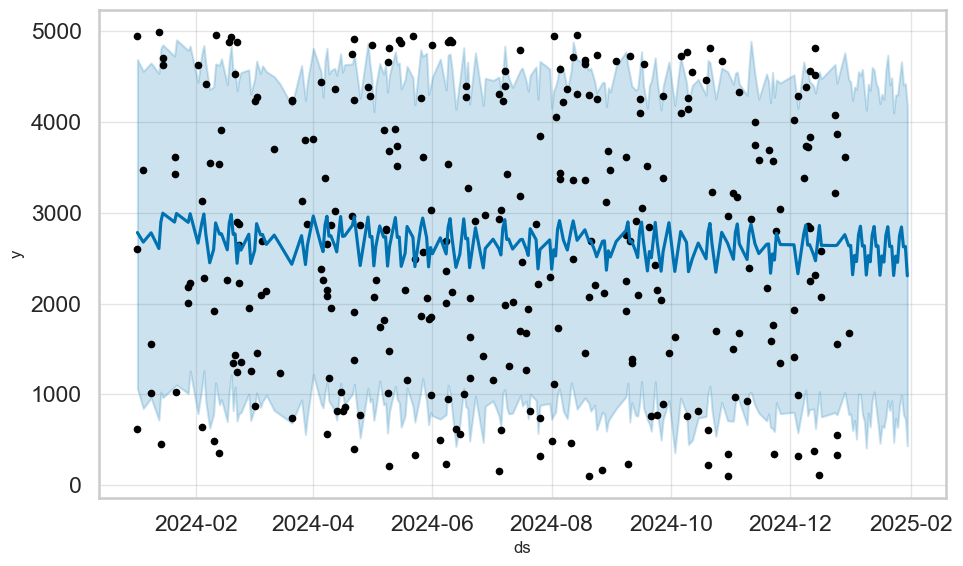

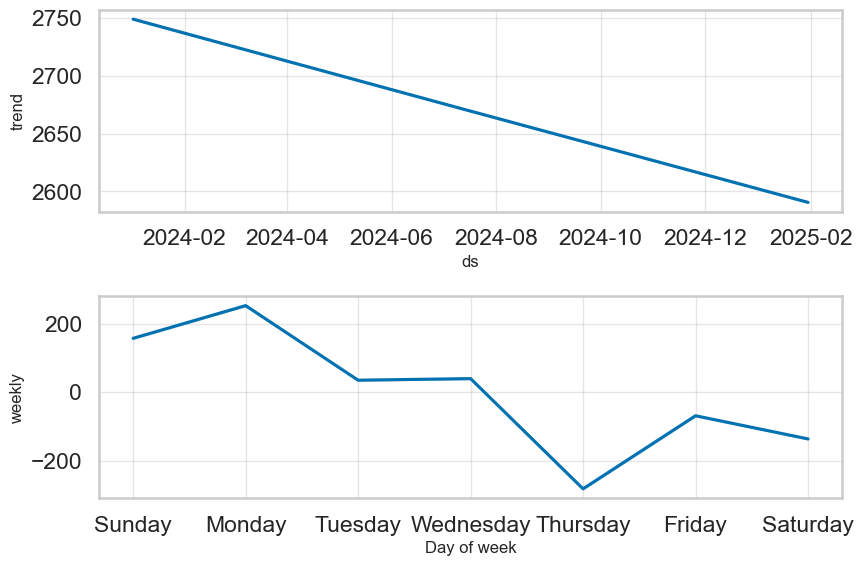

In [13]:
from prophet import Prophet

# Prepare data
forecast_df = df[['Date', 'Amount']].rename(columns={'Date': 'ds', 'Amount': 'y'})

# Model
model = Prophet()
model.fit(forecast_df)

# Future dates (30 days)
future = model.make_future_dataframe(periods=30)

# Prediction
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)

# Components (trend & seasonality)
model.plot_components(forecast)


---
## 14. Linear Regression 

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Fix column name (if needed)
df.rename(columns={'Payment Mode': 'Payment_Mode'}, inplace=True)

# Convert categorical to numeric
df_encoded = pd.get_dummies(df, drop_first=True)

# Drop unnecessary columns safely
X = df_encoded.drop(columns=['Amount', 'Date'], errors='ignore')
y = df_encoded['Amount']

# IMPORTANT: Remove Date if still present (datetime issue)
if 'Date' in X.columns:
    X = X.drop('Date', axis=1)

# Fill missing values (important)
X = X.fillna(0)

# Check data
print("X shape:", X.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


X shape: (300, 18)
MAE: 1311.3299883824752
R2 Score: -0.06795808477847154


---
## 15. KMeans Clustering

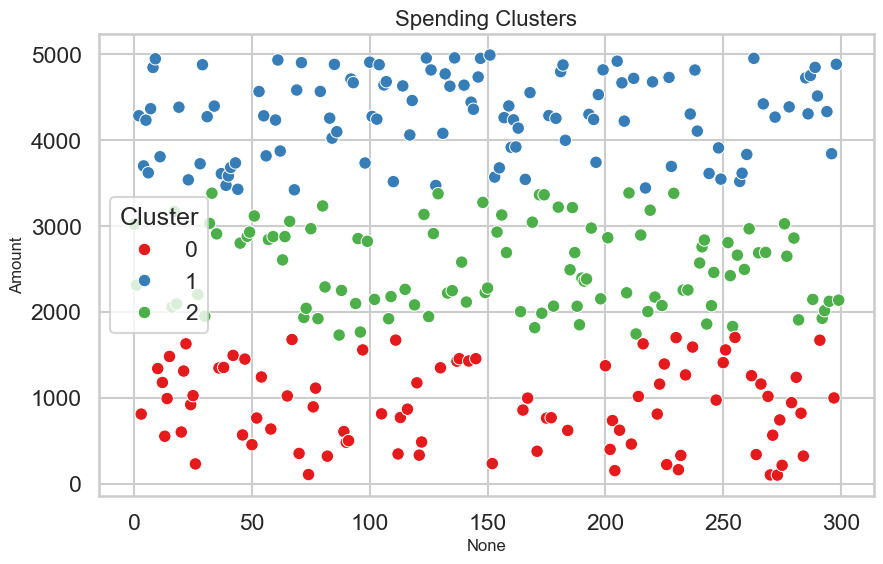

In [15]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Using Amount for clustering
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

X = df[['Amount','Category_encoded']]



# Model
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualization
plt.figure()
sns.scatterplot(x=df.index, y=df['Amount'], hue=df['Cluster'], palette='Set1')
plt.title("Spending Clusters")
plt.show()


---
## 16. Isolation Forest 
### (Isolation Forest detects unusual or abnormal spending patterns)

Anomalies detected:
          Date       Category  Amount Payment_Mode Description  Month  \
13  2024-12-25         Travel     555         Card     Expense     12   
26  2024-09-09          Bills     233         Card     Expense      9   
61  2024-02-19         Travel    4935         Card     Expense      2   
74  2024-12-16          Bills     109          UPI     Expense     12   
136 2024-02-11  Entertainment    4959         Cash     Expense      2   
151 2024-01-13  Entertainment    4992          UPI     Expense      1   
152 2024-06-08          Bills     237         Card     Expense      6   
171 2024-12-13          Bills     380         Card     Expense     12   
202 2024-04-22          Bills     402         Cash     Expense      4   
204 2024-07-05  Entertainment     155          UPI     Expense      7   
226 2024-10-20           Food     225         Cash     Expense     10   
231 2024-08-27           Food     166         Card     Expense      8   
270 2024-08-20       Shopping  

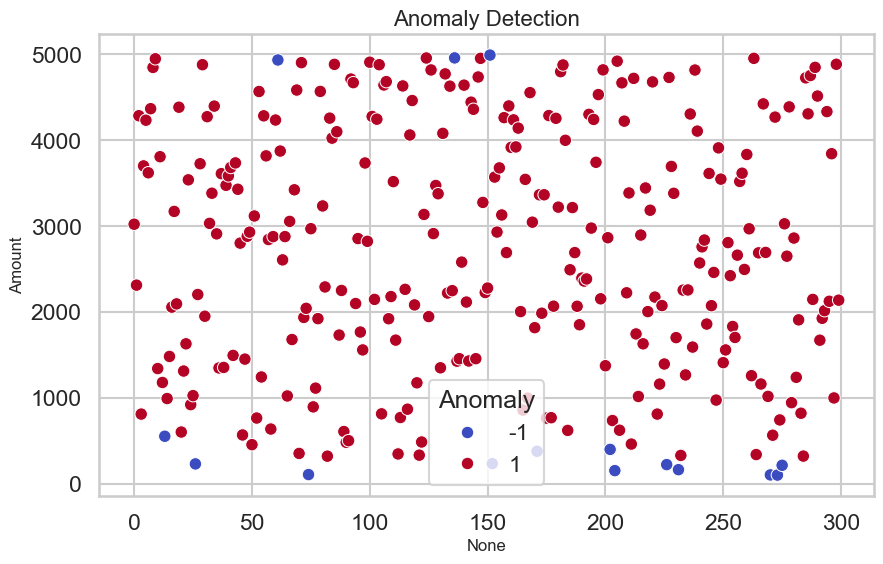

In [16]:
from sklearn.ensemble import IsolationForest

# Model
iso = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = iso.fit_predict(df[['Amount']])

# Show anomalies
anomalies = df[df['Anomaly'] == -1]

print("Anomalies detected:")
print(anomalies)

# Plot
plt.figure()
sns.scatterplot(x=df.index, y=df['Amount'], hue=df['Anomaly'], palette='coolwarm')
plt.title("Anomaly Detection")
plt.show()


# 17. Insights 

- Food and shopping contribute significantly to overall expenses.
- Digital payment methods such as UPI are used more frequently than cash.
- Spending varies across different months, indicating seasonal financial behavior.
- Some categories show occasional spikes in spending.
- The heatmap reveals patterns of higher spending in certain months and categories.


# 18. Conclusion

The SpendSense project analyzes personal spending data using Python and data visualization techniques. 
Through various charts and analytical methods, the project identifies spending patterns across categories, 
payment modes, and months. These insights can help individuals better understand their financial habits 
and make more informed budgeting decisions.

